In [13]:
# This block installs the main libraries required for single-cell RNA-seq analysis,
# including Scanpy for data processing and visualization.

%pip install scanpy scipy pandas anndata leidenalg --quiet

Note: you may need to restart the kernel to use updated packages.


In [17]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything works!")

Everything works!


In [16]:
# Download metadata file from GEO database.
# The metadata file contains information about all cells in the dataset,
# including sample identity, barcode information, and QC-related metrics.

!curl -L -O https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM8721nnn/GSM8721081/suppl/GSM8721081_cell_metadata.csv.gz

# Unzip metadata file
!gzip -dk GSM8721081_cell_metadata.csv.gz

# Load metadata table
meta = pd.read_csv("GSM8721081_cell_metadata.csv")

print(meta.shape)
meta.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 29.7M  100 29.7M    0     0  1535k      0  0:00:19  0:00:19 --:--:-- 2440k
(2590816, 12)


,bc_wells,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well
0,17_01_01__s1,H1806_1_ctrl,hg38,85,97,134,17,1,1,B5,A1,A1
1,17_01_02__s1,H1806_1_ctrl,hg38,38,43,66,17,1,2,B5,A1,A2
2,17_01_04__s1,H1806_1_ctrl,hg38,37,43,59,17,1,4,B5,A1,A4
3,17_01_05__s1,H1806_1_ctrl,hg38,26,27,31,17,1,5,B5,A1,A5
4,17_01_07__s1,H1806_1_ctrl,hg38,38,43,64,17,1,7,B5,A1,A7


In [10]:
# Selecting MDA-MB-231 cells

# This step filters the dataset to retain only cells belonging
# to the MB231_initial sample.

# A random subset of 50,000 cells is selected to reduce
# computational cost while keeping the analysis reproducible.

mb231 = meta[meta["sample"] == "MB231_initial"]

print("MB231 cells:", mb231.shape)

mb231_50k = mb231.sample(50000, random_state=0)

print("Selected cells:", mb231_50k.shape)

# Extract barcode identifiers
barcodes = mb231_50k["bc_wells"]

barcodes.head()

NameError: name 'meta' is not defined

In [ ]:
# Downloading the count matrix

# The raw count matrix contains gene expression values
# for all cells and genes in sparse matrix format.

!wget -c https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM8721nnn/GSM8721081/suppl/GSM8721081_count_matrix.mtx.gz

# Unzip count matrix
!gzip -dk GSM8721081_count_matrix.mtx.gz

In [ ]:
# Convert metadata indices to matrix-compatible indices

indices = mb231_50k.index + 1

# Create set of selected cell indices
selected_cells = set(indices)

print("Selected cell indices:", len(selected_cells))

In [ ]:
# Extracting expression data for selected cells

# Because the full count matrix is very large,
# it is processed in chunks. Only rows corresponding
# to the selected MB231 cells are retained and
# reconstructed into a sparse expression matrix.

rows = []
cols = []
vals = []

for chunk in pd.read_csv(
    "GSM8721081_count_matrix.mtx",
    sep=" ",
    comment="%",
    skiprows=3,
    header=None,
    names=["cell", "gene", "value"],
    chunksize=5_000_000
):

    subset = chunk[chunk["cell"].isin(selected_cells)]

    rows.extend(subset["cell"].values - 1)
    cols.extend(subset["gene"].values - 1)
    vals.extend(subset["value"].values)

print("Done reading matrix chunks")

subset_matrix = sp.coo_matrix(
    (vals, (rows, cols)),
    shape=(2590816, 63142)
).tocsr()

subset_matrix = subset_matrix[mb231_50k.index, :]

print(subset_matrix.shape)

In [ ]:
# Creating the AnnData object

# The filtered expression matrix is converted into an AnnData object,
# which is the standard Scanpy structure for single-cell analysis.

adata = sc.AnnData(X=subset_matrix)

adata.obs = mb231_50k.copy()

print(adata)

In [ ]:
# Saving the initial subset

# The selected subset of MDA-MB-231 cells is saved as an .h5ad file
# for downstream analysis.

adata.write("MB231_initial_50k.h5ad")

print("Saved: MB231_initial_50k.h5ad")

In [ ]:
# Loading gene annotations from GSM8721081_all_genes.csv

# Gene annotations are loaded and assigned to the dataset
# so genes can be referenced using gene symbols instead
# of numeric indices.

genes = pd.read_csv("GSM8721081_all_genes.csv")

adata.var = genes.copy()

adata.var_names = genes["gene_name"].astype(str)

adata.var_names_make_unique()

adata.var["gene_name"] = adata.var_names

adata.var.index.name = None

print("Genes loaded:", adata.n_vars)

In [ ]:
# Calculating quality control metrics

# Mitochondrial genes are identified using the MT- prefix.
# QC metrics such as genes per cell, counts per cell,
# and mitochondrial percentage are then calculated.

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

print("Before QC:", adata.shape)

In [ ]:
sc.pl.violin(
    adata,
    ["pct_counts_mt"]
)

In [ ]:
# Quality control filtering

# Low-quality cells, potential doublets,
# and stressed cells are removed using
# threshold-based filtering.

adata = adata[
    (adata.obs["n_genes_by_counts"] >= 40) &
    (adata.obs["n_genes_by_counts"] <= 1500) &
    (adata.obs["pct_counts_mt"] <= 10),
    :
].copy()

# Filtering rare genes

# Genes detected in fewer than three cells
# are removed because they contribute little
# biological information and mostly add noise.

sc.pp.filter_genes(
    adata,
    min_cells=3
)

print("After QC:", adata.shape)

In [ ]:
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1)

plt.hist(
    adata.obs["n_genes"],
    bins=50
)

plt.xlabel("Genes per cell")
plt.ylabel("Number of cells")
plt.title("Genes per cell (after QC)")
plt.xlim(0, 300)

plt.show()

In [ ]:
# QC visualization

# Histograms and scatter plots are used to inspect
# the distributions of genes per cell and counts
# per cell after quality control filtering.

plt.figure(figsize=(6,5))

plt.scatter(
    adata.obs["total_counts"],
    adata.obs["n_genes_by_counts"],
    s=3,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Counts per cell")
plt.ylabel("Genes per cell")
plt.title("QC: genes vs counts")

plt.show()

In [ ]:
# Normalization

# Expression values are normalized so that each cell
# has the same total count value, correcting for
# differences in sequencing depth.

sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

In [ ]:
# Log transformation

# A log transformation is applied to reduce the effect
# of extreme expression values and stabilize variance
# across genes.

sc.pp.log1p(adata)

# Saving log-transformed data before scaling

# Scaling may have undesirable effects on the data,
# therefore the log-transformed dataset is stored
# before proceeding to downstream analysis.

adata.raw = adata.copy()

In [ ]:
adata.write("adata_normalized.h5ad")

print("Saved: adata_normalized.h5ad")

In [18]:
import os

print("CURRENT FOLDER:")
print(os.getcwd())

print("\nFILES HERE:")
print(os.listdir())

CURRENT FOLDER:
/Users/serafimaabakumova/Documents/mda_mb231_scRNA_project

FILES HERE:
['MB231_initial_50k.h5ad', '.DS_Store', 'Untitled.ipynb', 'GSM8721081_cell_metadata.csv.gz', 'pipeline.ipynb', '.ipynb_checkpoints', 'adata_normalized.h5ad', 'GSM8721081_cell_metadata.csv', 'GSM8721081_all_genes.csv']


In [19]:
adata = sc.read_h5ad("adata_normalized.h5ad")

Number of HVGs: 2000


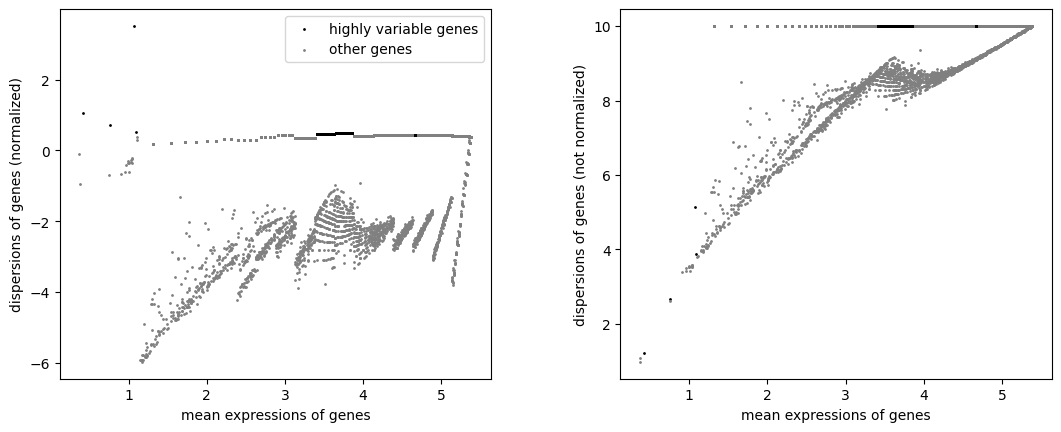

In [20]:
# Highly variable gene selection

# The top 2,000 highly variable genes are selected
# because they capture the major biological variation
# across cells.

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

print("Number of HVGs:", adata.var["highly_variable"].sum())

sc.pl.highly_variable_genes(adata)

In [22]:
# Scaling

# Gene expression values are standardized so that genes
# with large expression ranges do not dominate downstream analysis.

sc.pp.scale(
    adata,
    max_value=10
)

/var/folders/n0/lsp21sss7419mfhz1n4ykth00000gn/T/ipykernel_68914/3173265986.py:8: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(


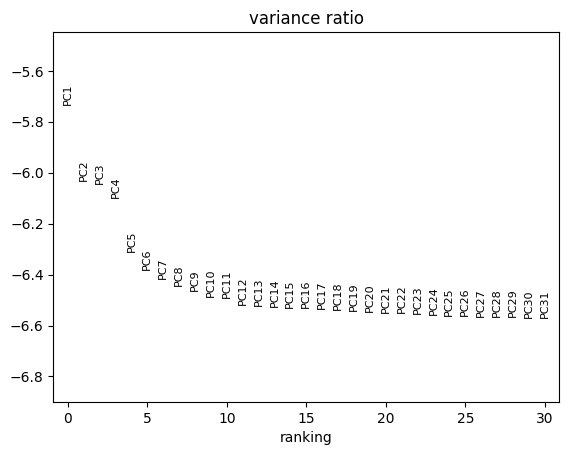

(24073, 50)
[0.00323189 0.00239903 0.00237343 0.00224912 0.00181552 0.00169323
 0.00163139 0.0015919  0.00156207 0.0015256 ]


In [24]:
# PCA

# PCA reduces the dimensionality of the dataset
# by transforming thousands of genes into a smaller
# number of principal components representing major
# transcriptional variation.

sc.tl.pca(
    adata,
    use_highly_variable=True,
    svd_solver="arpack"
)

sc.pl.pca_variance_ratio(
    adata,
    log=True
)

print(adata.obsm["X_pca"].shape)
print(adata.uns["pca"]["variance_ratio"][:10])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/n0/lsp21sss7419mfhz1n4ykth00000gn/T/ipykernel_68914/1040176738.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


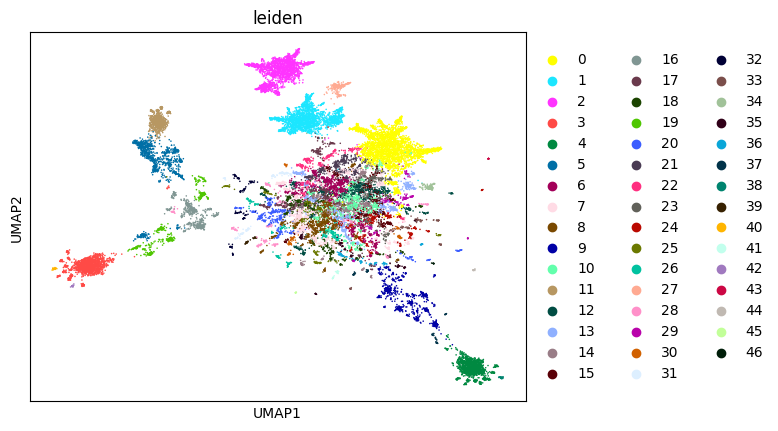

In [25]:
# UMAP embedding and Leiden clustering

# A k-nearest neighbor graph is constructed using PCA coordinates.
# UMAP is used for visualization, and Leiden clustering identifies
# groups of transcriptionally similar cells.

sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=20
)

sc.tl.umap(adata)

sc.tl.leiden(
    adata,
    resolution=0.5
)

sc.pl.umap(
    adata,
    color="leiden"
)

<Axes: xlabel='leiden'>

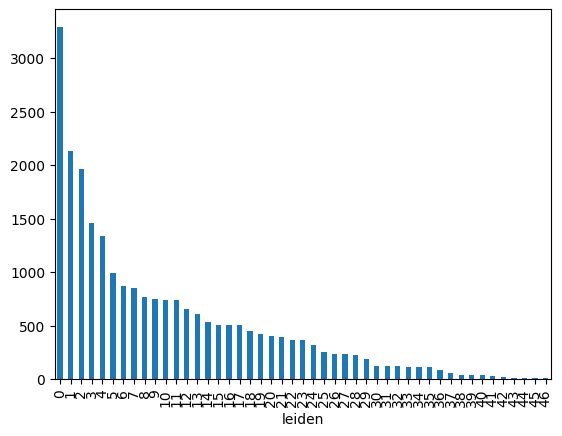

In [26]:
# Cluster size distribution

# The number of cells in each Leiden cluster is analyzed
# to examine the relative abundance of different transcriptional states.

adata.obs["leiden"].value_counts()
adata.obs["leiden"].value_counts().sort_index().plot(
    kind="bar"
)

In [27]:
# Marker genes

# Differential expression analysis is performed to identify genes
# that distinguish each Leiden cluster from all other cells in the dataset.

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    use_raw=True
)

markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.to_csv(
    "MB231_all_cluster_markers.csv",
    index=False
)

ValueError: Received `use_raw=True`, but `adata.raw` is empty.

In [ ]:
# Top 50 downregulated genes per cluster

# Genes with the lowest differential expression scores
# are extracted for each cluster to identify transcriptional
# programs that are relatively suppressed compared to
# the remaining cell population.

bottom50_markers = (
    markers
    .sort_values(
        ["group", "scores"],
        ascending=[True, True]
    )
    .groupby("group")
    .head(50)
)

bottom50_markers.to_csv(
    "MB231_bottom50_downregulated_genes_per_cluster.csv",
    index=False
)

bottom50_markers

In [ ]:
# Saving final results

# The final processed AnnData object is saved together with PCA coordinates,
# UMAP embedding, cluster assignments, and marker gene analysis results.

adata.write("final_adata.h5ad")

print("Saved: final_adata.h5ad")